In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from imageio import imread

import torch
import torch.nn.functional as F

In [3]:
# random image
img_n = 20
image = np.random.rand(img_n, img_n)

# convolution kernel
kernel_size = 7
Y, X = np.meshgrid(np.linspace(-3, 3, kernel_size), np.linspace(-3, 3, kernel_size))
kernel = np.exp(-(X**2 + Y**2) / 7)

kernel

array([[0.07642629, 0.15611805, 0.23965104, 0.27645305, 0.23965104,
        0.15611805, 0.07642629],
       [0.15611805, 0.31890656, 0.48954166, 0.56471812, 0.48954166,
        0.31890656, 0.15611805],
       [0.23965104, 0.48954166, 0.75147729, 0.8668779 , 0.75147729,
        0.48954166, 0.23965104],
       [0.27645305, 0.56471812, 0.8668779 , 1.        , 0.8668779 ,
        0.56471812, 0.27645305],
       [0.23965104, 0.48954166, 0.75147729, 0.8668779 , 0.75147729,
        0.48954166, 0.23965104],
       [0.15611805, 0.31890656, 0.48954166, 0.56471812, 0.48954166,
        0.31890656, 0.15611805],
       [0.07642629, 0.15611805, 0.23965104, 0.27645305, 0.23965104,
        0.15611805, 0.07642629]])

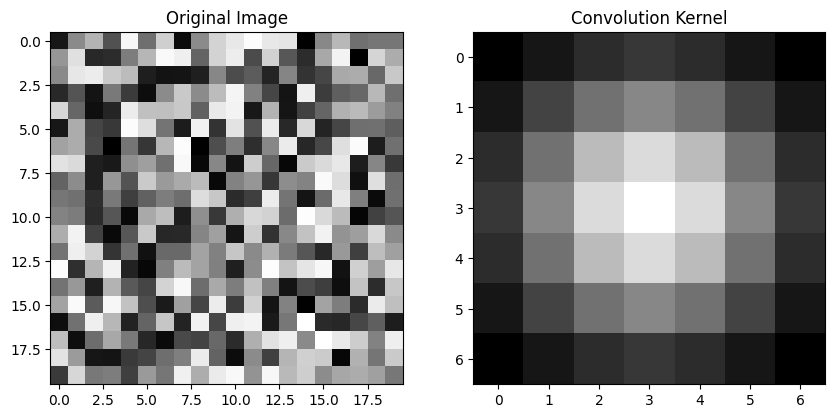

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')

ax[1].imshow(kernel, cmap='gray')
ax[1].set_title('Convolution Kernel')

plt.show()

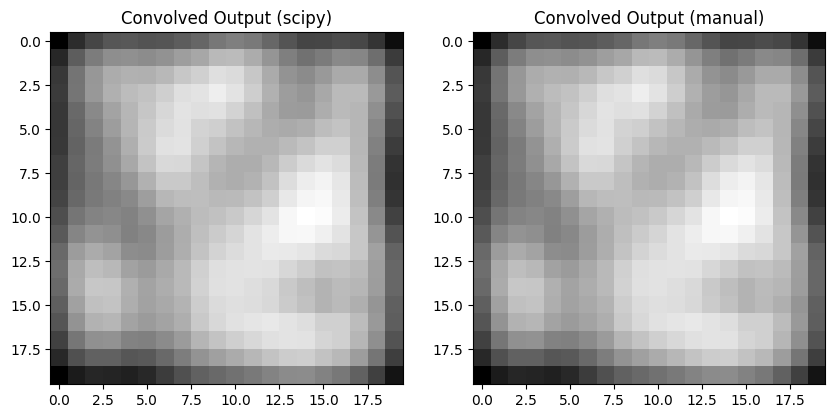

In [5]:
# convolve the image with the kernel
convolved_output = convolve2d(image, kernel, mode='same')

# convolve manually to check the output
# 1. Define the pad width (half the kernel size)
pad_val = kernel_size // 2

# 2. Create a padded version of the image (adds zeros around the edges)
# This makes the image larger so the kernel can "overhang" the edges
padded_image = np.pad(image, pad_val, mode='constant', constant_values=0)

manual_convolved_output = np.zeros_like(image)

for i in range(image.shape[0]):
    for j in range(image.shape[1]):
        # 3. Extract the region from the PADDED image
        # Because we padded, this slice will ALWAYS be (kernel_size, kernel_size)
        region = padded_image[i : i + kernel_size, j : j + kernel_size]
        
        # 4. Now the shapes match: (7,7) * (7,7)
        manual_convolved_output[i, j] = np.sum(region * kernel)

# plot the results
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(convolved_output, cmap='gray')
ax[0].set_title('Convolved Output (scipy)')
ax[1].imshow(manual_convolved_output, cmap='gray')
ax[1].set_title('Convolved Output (manual)')

plt.show()

C:\Users\Pablo\AppData\Local\Temp\ipykernel_2068\3861367374.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread(url)


Text(0.5, 1.0, 'Original Image')

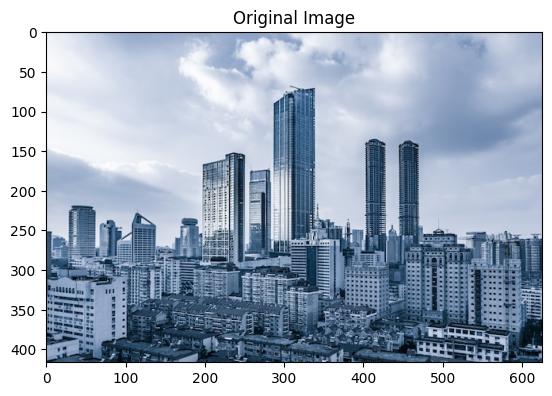

In [6]:
# get an image from python's image library
url = 'https://img.freepik.com/photos-gratuite/acier-entreprise-construction-urbaine-observation_1127-2397.jpg'
image = imread(url)

# plot it
plt.imshow(image)
plt.title('Original Image')

(417, 626)


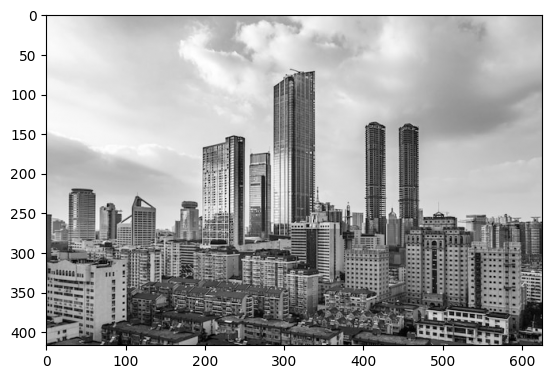

In [7]:
# transform the image to grayscale
# we can do this by taking the mean across the color channels (axis=-1)
# not necessary to do this for convolutional networks, but it can be useful for this example
# to save a little bit of code

grayscale_image = np.mean(image, axis=-1)
grayscale_image = grayscale_image / np.max(grayscale_image)  # normalize to [0, 1]
# plot the grayscale image
print(grayscale_image.shape)
plt.imshow(grayscale_image, cmap='gray')

In [8]:
# hand-crafted horizontal and vertical edge detection kernels
horizontal_edge_kernel = np.array([[ -1, -1, -1],
                                   [  0,  0,  0],
                                   [  1,  1,  1]])

vertical_edge_kernel = np.array([[ -1,  0,  1],
                                 [ -1,  0,  1],
                                 [ -1,  0,  1]])

# mode 'same' means the output will be the same size as the input, and the convolution will be centered on the input image
convolved_horizontal = convolve2d(grayscale_image, horizontal_edge_kernel, mode='same')
convolved_vertical = convolve2d(grayscale_image, vertical_edge_kernel, mode='same')

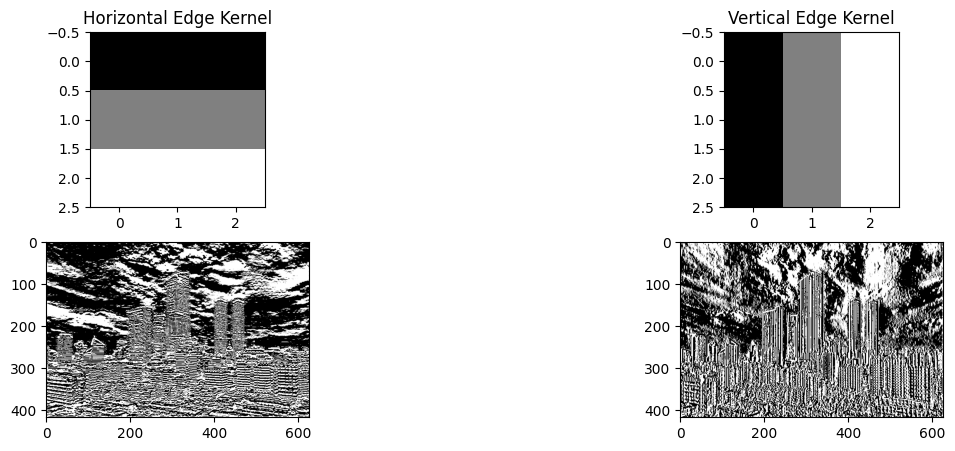

In [9]:
# plot the kernel and the convolved outputs
fig, ax = plt.subplots(2, 2, figsize=(15, 5))
ax[0, 0].imshow(horizontal_edge_kernel, cmap='gray')
ax[0, 0].set_title('Horizontal Edge Kernel')
ax[0, 1].imshow(vertical_edge_kernel, cmap='gray')
ax[0, 1].set_title('Vertical Edge Kernel')
ax[1, 0].imshow(convolved_horizontal, cmap='gray', vmin=0, vmax=0.01)
ax[1, 1].imshow(convolved_vertical, cmap='gray', vmin=0, vmax=0.01)

In [13]:
# view command it is used for convolution. It reshapes the kernels, 
# since pytorch expects the kernel to have the shape (out_channels, in_channels, kernel_height, kernel_width)
VK_t = torch.tensor(vertical_edge_kernel).view(1, 1, 3, 3).double()  # reshape to (out_channels, in_channels, kernel_height, kernel_width)
HK_t = torch.tensor(horizontal_edge_kernel).view(1, 1, 3, 3).double()  # reshape to (out_channels, in_channels, kernel_height, kernel_width)
image_t = torch.tensor(grayscale_image).view(1, 1, grayscale_image.shape[0], grayscale_image.shape[1])

print("Vertical Kernel previous shape:", vertical_edge_kernel.shape, "-> reshaped to:", VK_t.shape)
print("Horizontal Kernel previous shape:", horizontal_edge_kernel.shape, "-> reshaped to:", HK_t.shape)
print("Image previous shape:", grayscale_image.shape, "-> reshaped to:", image_t.shape)

Vertical Kernel previous shape: (3, 3) -> reshaped to: torch.Size([1, 1, 3, 3])
Horizontal Kernel previous shape: (3, 3) -> reshaped to: torch.Size([1, 1, 3, 3])
Image previous shape: (417, 626) -> reshaped to: torch.Size([1, 1, 417, 626])


In [ ]:
C = F.conv2d(image_t, VK_t)
print(C.shape) # we have lost 2 pixels on each side due to the convolution, so the output is smaller than the input

# to solve this we can use padding in the convolution
# in this case as kernel size is 3, we can use padding=1 to add a 1 pixel border around the input image
C_padded = F.conv2d(image_t, VK_t, padding=1)
print(C_padded.shape) # now the output is the same size as the input

torch.Size([1, 1, 415, 624])
torch.Size([1, 1, 417, 626])


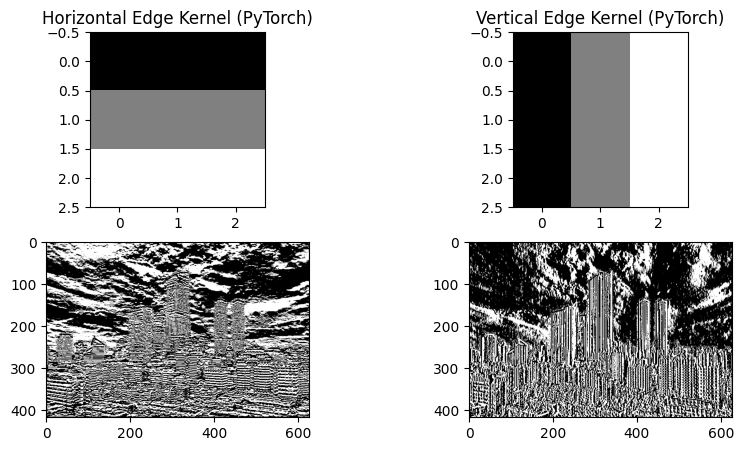

In [19]:
# run convolution for each kernel and show the results
C_horizontal = F.conv2d(image_t, HK_t, padding=1)
C_vertical = F.conv2d(image_t, VK_t, padding=1)

fig, ax = plt.subplots(2, 2, figsize=(10, 5))
ax[0, 0].imshow(HK_t.squeeze().numpy(), cmap='gray')
ax[0, 0].set_title('Horizontal Edge Kernel (PyTorch)')
ax[0, 1].imshow(VK_t.squeeze().numpy(), cmap='gray')
ax[0, 1].set_title('Vertical Edge Kernel (PyTorch)')
ax[1, 0].imshow(C_horizontal.squeeze().numpy(), cmap='gray', vmin=0, vmax=0.01)
ax[1, 1].imshow(C_vertical.squeeze().numpy(), cmap='gray', vmin=0, vmax=0.01)
plt.show()